[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Chava\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Chava\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\Chava\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


✅ Logistic Regression Accuracy: 0.7868852459016393

Classification Report:
               precision    recall  f1-score   support

    negative       0.79      0.96      0.87      1889
     neutral       0.70      0.39      0.50       580
    positive       0.84      0.59      0.69       459

    accuracy                           0.79      2928
   macro avg       0.78      0.64      0.69      2928
weighted avg       0.78      0.79      0.77      2928

✅ Random Forest Accuracy: 0.7762978142076503

Classification Report:
               precision    recall  f1-score   support

    negative       0.82      0.90      0.86      1889
     neutral       0.60      0.49      0.54       580
    positive       0.74      0.63      0.68       459

    accuracy                           0.78      2928
   macro avg       0.72      0.67      0.69      2928
weighted avg       0.77      0.78      0.77      2928

✅ Exported: sentiment_model.pkl + tfidf_vectorizer.pkl


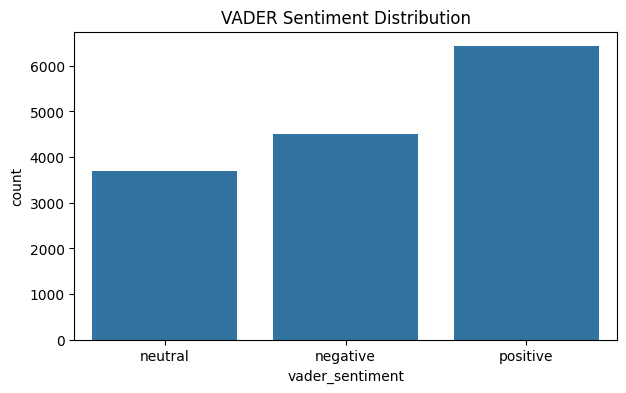

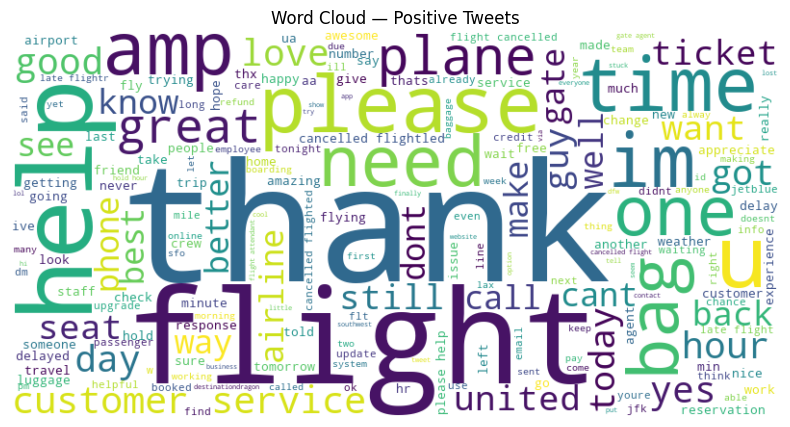

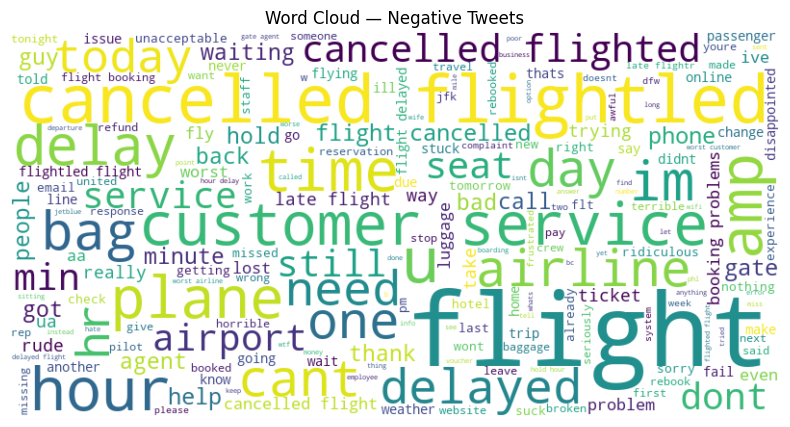

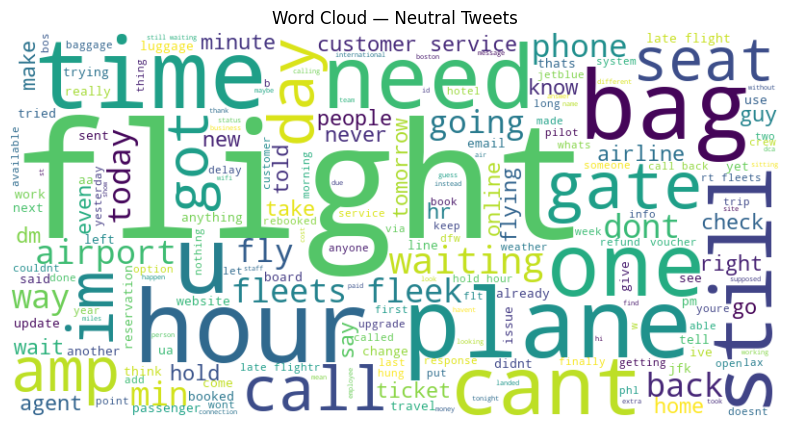

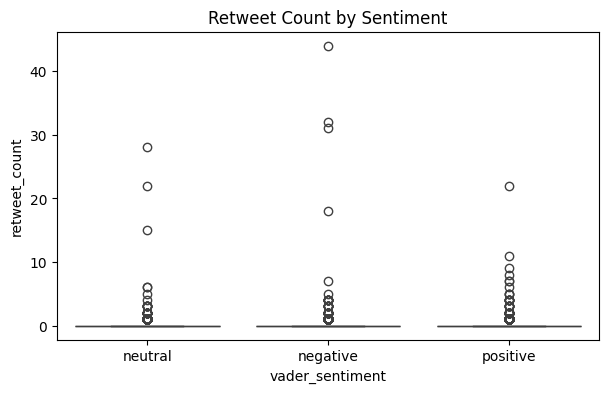

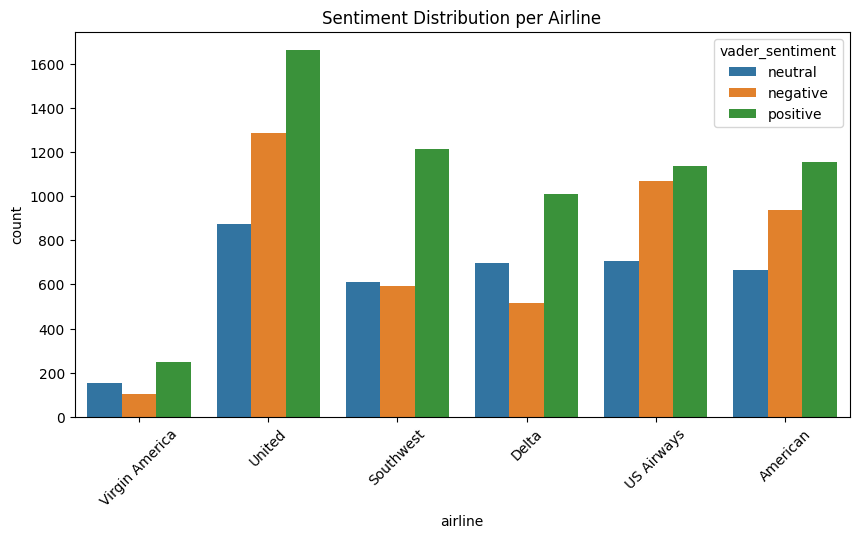

✅ Exported: airline_tweets_sentiment_dashboard.csv


In [4]:
# ===============================================================
# 🛫 Airline Tweet Sentiment Analysis — Full Pipeline Notebook
# ===============================================================
# This project processes 14,000+ tweets about major U.S airlines,
# applies NLP techniques, performs VADER sentiment labeling,
# trains ML models (Logistic Regression + Random Forest comparison),
# and exports clean datasets & lightweight models for Streamlit.
# ===============================================================


# ===============================================================
# 1. Import Libraries
# ===============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import pickle
import re


# ===============================================================
# 2. Load Dataset
# ===============================================================
df = pd.read_csv("Tweets.csv")

# Select only important columns
cols = ['text', 'airline', 'airline_sentiment']
if 'retweet_count' in df.columns:
    cols.append('retweet_count')

df = df[cols]
df.head()


# ===============================================================
# 3. Text Preprocessing
# ===============================================================
nltk.download('stopwords')
nltk.download('vader_lexicon')

stop_words = set(stopwords.words('english'))

def preprocess_texts(texts):
    """
    Cleans tweets by removing:
    - URLs
    - Mentions
    - Hashtags
    - Special characters
    - Stopwords
    Returns lowercase cleaned text.
    """
    def clean(text):
        text = str(text).lower()
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)      # URLs
        text = re.sub(r"@\w+", "", text)                         # Mentions
        text = re.sub(r"#", "", text)                            # Hashtag symbol
        text = re.sub(r"[^a-zA-Z\s]", "", text)                  # Special chars
        text = " ".join([w for w in text.split() if w not in stop_words])
        return text
    
    return texts.apply(clean)

df["clean_text"] = preprocess_texts(df["text"])
df.head()


# ===============================================================
# 4. VADER Sentiment Analysis (Rule-Based NLP)
# ===============================================================
sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    """
    Converts VADER compound score to sentiment label:
    - > 0.05 → positive
    - < -0.05 → negative
    - otherwise → neutral
    """
    score = sia.polarity_scores(text)["compound"]
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df["vader_sentiment"] = df["clean_text"].apply(vader_sentiment)
df.head()


# ===============================================================
# 5. Machine Learning Model — Logistic Regression (Main Model)
# ===============================================================
# TF-IDF feature extraction
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df["clean_text"])
y = df["airline_sentiment"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ Logistic Regression (Lightweight & Streamlit-Friendly)
lr_model = LogisticRegression(max_iter=400, solver="liblinear")
lr_model.fit(X_train, y_train)

# Predictions
df["lr_predicted"] = lr_model.predict(X)

# Evaluation
y_pred_lr = lr_model.predict(X_test)
print("✅ Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


# ===============================================================
# 6. (Optional) Random Forest Model — For Comparison Only
# ===============================================================
# ⚠ WARNING: RF models can be very large (>100MB)
# We DO NOT save it — only use for comparison

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, y_train)

df["rf_predicted"] = rf_model.predict(X)

y_pred_rf = rf_model.predict(X_test)
print("✅ Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


# ===============================================================
# 7. Save Final Lightweight Model & Vectorizer for Streamlit
# ===============================================================
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("✅ Exported: sentiment_model.pkl + tfidf_vectorizer.pkl")


# ===============================================================
# 8. Exploratory Data Analysis (EDA)
# ===============================================================

# -------------------- 8A. Sentiment Distribution --------------------
plt.figure(figsize=(7, 4))
sns.countplot(x=df["vader_sentiment"])
plt.title("VADER Sentiment Distribution")
plt.show()

# -------------------- 8B. Word Clouds per Sentiment --------------------
def plot_wordcloud(label):
    text = " ".join(df[df["vader_sentiment"] == label]["clean_text"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f"Word Cloud — {label.capitalize()} Tweets")
    plt.axis("off")
    plt.show()

plot_wordcloud("positive")
plot_wordcloud("negative")
plot_wordcloud("neutral")

# -------------------- 8C. Retweet Count Analysis --------------------
if "retweet_count" in df.columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df["vader_sentiment"], y=df["retweet_count"])
    plt.title("Retweet Count by Sentiment")
    plt.show()

# -------------------- 8D. Airline-Level Sentiment Comparison --------------------
plt.figure(figsize=(10, 5))
sns.countplot(x=df["airline"], hue=df["vader_sentiment"])
plt.title("Sentiment Distribution per Airline")
plt.xticks(rotation=45)
plt.show()


# ===============================================================
# 9. Export Processed Dataset for Streamlit Dashboard
# ===============================================================
df.to_csv("airline_tweets_sentiment_dashboard.csv", index=False)
print("✅ Exported: airline_tweets_sentiment_dashboard.csv")
